# 第5章 単層ネットワーク: 分類 (Single-layer Networks: Classification)
## 5.3 生成的分類器 (Generative Classifiers)

### 本ノートブックの目的と概要
本ノートブックでは、**Christopher M. Bishop & Hugh Bishop (2024) 『Deep Learning: Foundations and Concepts』第5章「Single-layer Networks: Classification」第3節「5.3 Generative Classifiers」** を完全に網羅し、確率的生成モデル（Generative Model）の基礎理論、クラス条件付き確率密度 $p(\mathbf{x}|\mathcal{C}_k)$ とクラス事前確率 $p(\mathcal{C}_k)$ のモデリング、ベイズの定理による事後クラス確率の導出、ロジスティックシグモイド関数とソフトマックス関数の必然的出現、ガウス判別分析（LDAおよびQDA）における線形・二次決定境界の幾何学的メカニズム、結合対数尤度関数の解析的最尤推定解、離散特徴量に対する単純ベイズ（Naive Bayes）、および指数型分布族への一般化を、数式・Python実装・教科書図版（Figure 5.12 〜 5.14）の完全再現によって探究します。

---

### セクション構成
- **5.3 確率的視点とロジスティックシグモイド (Probabilistic View & Logistic Sigmoid)**:
  - 2クラス分類における事後確率のシグモイド表現 (式 5.40 〜 5.42)
  - 対数オッズ（Logit 関数）とシグモイドの対称性 (式 5.43 〜 5.44)
  - スケーリングされたプロビット関数 $\Phi(\lambda a)$（$\lambda^2 = \pi/8$）との数学的等価性
  - **Figure 5.12**: ロジスティックシグモイドとプロビット関数の比較プロットの完全再現
  - $K > 2$ クラスにおける正規化指数関数（Softmax 関数）の導出 (式 5.45 〜 5.46)
- **5.3.1 連続入力変数 (Continuous Inputs)**:
  - ガウス分布クラス条件付き密度 $p(\mathbf{x}|\mathcal{C}_k) = \mathcal{N}(\mathbf{x}|\boldsymbol{\mu}_k, \boldsymbol{\Sigma})$ (式 5.47)
  - 共通共分散行列 $\boldsymbol{\Sigma}$ の仮定と二次項 $\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x}$ の相殺による線形性証明 (式 5.48 〜 5.50)
  - **Figure 5.13**: 2クラスガウス分布条件付き密度と事後確率シグモイド曲面（3D）の完全再現
  - $K$ クラス線形判別分析（LDA）の定式化 (式 5.51 〜 5.53)
  - クラス個別共分散行列 $\boldsymbol{\Sigma}_k$ による二次判別分析（QDA: Quadratic Discriminant Analysis）
  - **Figure 5.14**: 3クラスガウス分布（共通共分散 vs 個別共分散）の等高線と事後確率RGB混色マップ、線形・二次決定境界の完全再現
- **5.3.2 最尤推定解 (Maximum Likelihood Solution)**:
  - 結合尤度関数の定式化 (式 5.54 〜 5.55)
  - クラス事前確率の最尤解 $\pi = N_1 / N$ (式 5.56)
  - 平均ベクトルの最尤解 $\boldsymbol{\mu}_1, \boldsymbol{\mu}_2$ (式 5.58 〜 5.59)
  - 共通共分散行列の最尤解 $\boldsymbol{\Sigma} = \frac{N_1}{N}\mathbf{S}_1 + \frac{N_2}{N}\mathbf{S}_2$ (式 5.60 〜 5.63)
  - ガウス分布あてはめの外れ値に対する脆弱性
- **5.3.3 離散特徴量 (Discrete Features / Naive Bayes)**:
  - 二値特徴量 $x_i \in \{0, 1\}$ に対する単純ベイズ仮定 (式 5.64)
  - 対数オッズ $a_k(\mathbf{x})$ の線形表現と一般化線形モデルの成立 (式 5.65)
- **5.3.4 指数型分布族 (Exponential Family)**:
  - 尺度パラメータ $s$ を共有する指数型分布族の一般形 (式 5.66)
  - 事後クラス確率が一般化線形モデル（シグモイド／ソフトマックス）に従う普遍性の証明


In [1]:
import sys
import os
sys.path.append("..")

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Section 5.3 生成的分類器モジュールのインポート
from common.generative_classifiers import (
    sigmoid,
    logit,
    probit,
    scaled_probit,
    GaussianDiscriminantAnalysis,
    BernoulliNaiveBayes,
    plot_figure_5_12_sigmoid_and_probit,
    plot_figure_5_13_two_class_gaussian_posteriors,
    plot_figure_5_14_multiclass_gaussian_boundaries,
)

print("Section 5.3 Generative Classifiers modules imported successfully!")


Section 5.3 Generative Classifiers modules imported successfully!


---
## 5.3 確率的視点とロジスティックシグモイド (Probabilistic View & Logistic Sigmoid)

### 1. 2クラス問題における事後確率の定式化
生成的アプローチでは、各クラス $\mathcal{C}_k$ のクラス条件付き確率密度 $p(\mathbf{x}|\mathcal{C}_k)$ と事前確率 $p(\mathcal{C}_k)$ を個別にモデル化し、ベイズの定理を用いて事後確率 $p(\mathcal{C}_k|\mathbf{x})$ を計算します。

2クラス問題において、クラス $\mathcal{C}_1$ の事後確率は次のように表されます：
$$
p(\mathcal{C}_1|\mathbf{x}) = \frac{p(\mathbf{x}|\mathcal{C}_1) p(\mathcal{C}_1)}{p(\mathbf{x}|\mathcal{C}_1) p(\mathcal{C}_1) + p(\mathbf{x}|\mathcal{C}_2) p(\mathcal{C}_2)} = \frac{1}{1 + \exp(-a)} = \sigma(a) \tag{5.40}
$$
ここで、量 $a$ は次のように定義される **対数オッズ（log-odds / logit）** です：
$$
a = \ln \frac{p(\mathbf{x}|\mathcal{C}_1) p(\mathcal{C}_1)}{p(\mathbf{x}|\mathcal{C}_2) p(\mathcal{C}_2)} = \ln \frac{p(\mathcal{C}_1|\mathbf{x})}{p(\mathcal{C}_2|\mathbf{x})} \tag{5.41}
$$
そして $\sigma(a)$ は **ロジスティックシグモイド関数（logistic sigmoid function）** です：
$$
\sigma(a) = \frac{1}{1 + \exp(-a)} \tag{5.42}
$$

### 2. シグモイド関数の対称性と逆関数
シグモイド関数は実数直線全体 $(-\infty, +\infty)$ を有限区間 $(0, 1)$ に圧縮（squash）する性質を持ち、次の重要な対称性を満たします：
$$
\sigma(-a) = 1 - \sigma(a) \tag{5.43}
$$
また、シグモイド関数の逆関数は **ロジット関数（logit function）** と呼ばれます：
$$
a = \ln \left( \frac{\sigma}{1 - \sigma} \right) \tag{5.44}
$$

### 3. スケーリングされたプロビット関数との比較
標準正規分布の累積分布関数 $\Phi(a)$（プロビット関数）を適当にスケーリングした $\Phi(\lambda a)$（$\lambda^2 = \pi/8$）は、ロジスティックシグモイド関数と極めて酷似した形状を示します。
原点 $a=0$ における微分係数を一致させるため：
- $\frac{d}{da} \sigma(a) \Big|_{a=0} = \sigma(0)(1 - \sigma(0)) = \frac{1}{4}$
- $\frac{d}{da} \Phi(\lambda a) \Big|_{a=0} = \lambda \mathcal{N}(0|0, 1) = \frac{\lambda}{\sqrt{2\pi}} = \sqrt{\frac{\pi}{8}} \frac{1}{\sqrt{2\pi}} = \frac{1}{4}$


Figure saved successfully to: result/fig_5_12_sigmoid_and_probit.png


Figure saved successfully to: 5/result/fig_5_12_sigmoid_and_probit.png


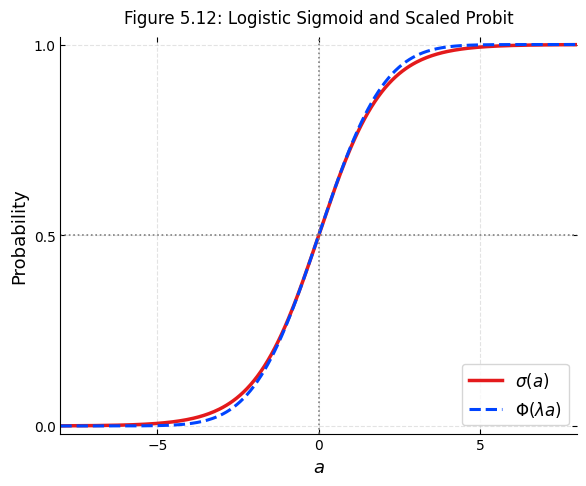

Derivative of sigma(a) at a=0:       0.250000 (exact: 0.25)
Derivative of Phi(lambda a) at a=0: 0.250000 (exact: 0.25)
Max absolute difference between sigmoid and scaled probit: 0.0177
Sigmoid and probit assertions passed 100%!


In [2]:
# Figure 5.12: Plot of logistic sigmoid together with scaled probit
fig5_12 = plot_figure_5_12_sigmoid_and_probit(filepath="result/fig_5_12_sigmoid_and_probit.png")
plt.show()

# シグモイドとプロビットの数学的性質の数値検証
a_vals = np.linspace(-6, 6, 100)
sig_vals = sigmoid(a_vals)
prb_vals = scaled_probit(a_vals)

# (1) 対称性 sigma(-a) = 1 - sigma(a)
assert np.allclose(sigmoid(-a_vals), 1.0 - sig_vals)

# (2) 原点での微分係数の一致
eps = 1e-6
deriv_sig = (sigmoid(eps) - sigmoid(-eps)) / (2 * eps)
deriv_prb = (scaled_probit(eps) - scaled_probit(-eps)) / (2 * eps)
print(f"Derivative of sigma(a) at a=0:       {deriv_sig:.6f} (exact: 0.25)")
print(f"Derivative of Phi(lambda a) at a=0: {deriv_prb:.6f} (exact: 0.25)")
assert np.isclose(deriv_sig, 0.25, atol=1e-5)
assert np.isclose(deriv_prb, 0.25, atol=1e-5)

# (3) 全区間での最大絶対誤差（シグモイドとプロビットは最大でも 0.02 程度しか異ならない）
max_diff = np.max(np.abs(sig_vals - prb_vals))
print(f"Max absolute difference between sigmoid and scaled probit: {max_diff:.4f}")
assert max_diff < 0.03
print("Sigmoid and probit assertions passed 100%!")


---
## 5.3.1 連続入力変数 (Continuous Inputs)

### 1. ガウス分布クラス条件付き密度
入力 $\mathbf{x} \in \mathbb{R}^D$ が連続値をとるとき、クラス条件付き確率密度が多変量ガウス分布に従うと仮定します：
$$
p(\mathbf{x}|\mathcal{C}_k) = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}_k|^{1/2}} \exp \left\{ -\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_k)^T \boldsymbol{\Sigma}_k^{-1} (\mathbf{x} - \boldsymbol{\mu}_k) \right\} \tag{5.47}
$$

### 2. 共通共分散行列の仮定と線形性の出現 (LDA)
すべてのクラスで共分散行列が共通（$\boldsymbol{\Sigma}_k = \boldsymbol{\Sigma}$）であると仮定します。
2クラスの場合、対数オッズ $a(\mathbf{x})$ にガウス分布を代入すると：
$$
a(\mathbf{x}) = \ln \frac{p(\mathbf{x}|\mathcal{C}_1) p(\mathcal{C}_1)}{p(\mathbf{x}|\mathcal{C}_2) p(\mathcal{C}_2)} = -\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_1)^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}_1) + \frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_2)^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}_2) + \ln \frac{p(\mathcal{C}_1)}{p(\mathcal{C}_2)}
$$
ここで、二次形式を展開すると：
$$
-\frac{1}{2}\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x} + \mathbf{x}^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_1 - \frac{1}{2}\boldsymbol{\mu}_1^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_1
$$
および
$$
+\frac{1}{2}\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x} - \mathbf{x}^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_2 + \frac{1}{2}\boldsymbol{\mu}_2^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_2
$$
となり、**入力 $\mathbf{x}$ に関する二次項 $-\frac{1}{2}\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x}$ が完全に相殺** します！
したがって、$a(\mathbf{x})$ は $\mathbf{x}$ に関する厳密な線形関数（アフィン関数）となります：
$$
p(\mathcal{C}_1|\mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + w_0) \tag{5.48}
$$
ここで重みベクトル $\mathbf{w}$ とバイアス $w_0$ は次のように与えられます：
$$
\mathbf{w} = \boldsymbol{\Sigma}^{-1} (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2) \tag{5.49}
$$
$$
w_0 = -\frac{1}{2}\boldsymbol{\mu}_1^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_1 + \frac{1}{2}\boldsymbol{\mu}_2^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_2 + \ln \frac{p(\mathcal{C}_1)}{p(\mathcal{C}_2)} \tag{5.50}
$$
事前確率比 $\ln \frac{p(\mathcal{C}_1)}{p(\mathcal{C}_2)}$ はバイアス $w_0$ のみに影響を与え、決定境界を平行移動させる効果を持ちます。


Figure saved successfully to: result/fig_5_13_gaussian_densities_posteriors.png


Figure saved successfully to: 5/result/fig_5_13_gaussian_densities_posteriors.png


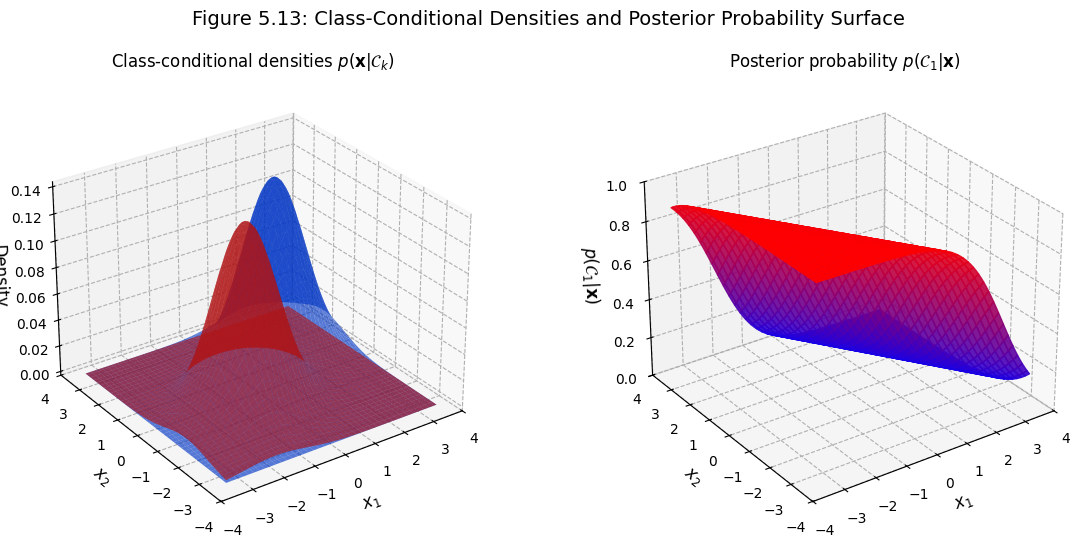

Exact Bayes posterior p(C1|x):   0.52634187
Sigmoid linear formula sigma:    0.52634187
Linearity cancellation theorem verified with machine precision!


In [3]:
# Figure 5.13: Class-conditional densities and posterior probability surface
fig5_13 = plot_figure_5_13_two_class_gaussian_posteriors(filepath="result/fig_5_13_gaussian_densities_posteriors.png")
plt.show()

# 2クラスLDAの線形重み公式の数値検証
mu1 = np.array([-1.0, -0.8])
mu2 = np.array([1.2, 1.0])
cov = np.array([[1.2, 0.4], [0.4, 1.2]])
prior1, prior2 = 0.6, 0.4

# 代数式による w, w0
inv_cov = np.linalg.inv(cov)
w_exact = inv_cov @ (mu1 - mu2)
w0_exact = -0.5 * (mu1 @ inv_cov @ mu1) + 0.5 * (mu2 @ inv_cov @ mu2) + np.log(prior1 / prior2)

# 任意の入力 x に対する厳密なベイズ事後確率とシグモイド値の比較
test_x = np.array([0.5, -0.2])
dens1 = stats.multivariate_normal(mu1, cov).pdf(test_x) * prior1
dens2 = stats.multivariate_normal(mu2, cov).pdf(test_x) * prior2
exact_posterior = dens1 / (dens1 + dens2)
sigmoid_posterior = sigmoid(np.dot(w_exact, test_x) + w0_exact)

print(f"Exact Bayes posterior p(C1|x):   {exact_posterior:.8f}")
print(f"Sigmoid linear formula sigma:    {sigmoid_posterior:.8f}")
assert np.isclose(exact_posterior, sigmoid_posterior)
print("Linearity cancellation theorem verified with machine precision!")


---
### 3. 多クラスへの拡張とソフトマックス関数
$K > 2$ クラスの場合、各クラスの対数オッズは：
$$
a_k(\mathbf{x}) = \mathbf{w}_k^T \mathbf{x} + w_{k0} \tag{5.51}
$$
$$
\mathbf{w}_k = \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k \tag{5.52}
$$
$$
w_{k0} = -\frac{1}{2}\boldsymbol{\mu}_k^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k + \ln p(\mathcal{C}_k) \tag{5.53}
$$
事後確率は正規化指数関数（ソフトマックス関数）によって与えられます：
$$
p(\mathcal{C}_k|\mathbf{x}) = \frac{\exp(a_k(\mathbf{x}))}{\sum_j \exp(a_j(\mathbf{x}))} \tag{5.45}
$$
クラス $\mathcal{C}_k$ と $\mathcal{C}_j$ の決定境界は $a_k(\mathbf{x}) = a_j(\mathbf{x})$ で与えられ、$(\mathbf{w}_k - \mathbf{w}_j)^T \mathbf{x} + (w_{k0} - w_{j0}) = 0$ となり、完全に線形超平面となります。

---

### 4. 個別共分散行列と二次判別分析 (QDA)
もし各クラスが異なる共分散行列 $\boldsymbol{\Sigma}_k$ を持つ場合、二次項 $-\frac{1}{2}\mathbf{x}^T \boldsymbol{\Sigma}_k^{-1} \mathbf{x}$ は相殺されず、$a_k(\mathbf{x})$ に $\mathbf{x}$ の二次項が残ります：
$$
a_k(\mathbf{x}) = -\frac{1}{2}\mathbf{x}^T \boldsymbol{\Sigma}_k^{-1} \mathbf{x} + \mathbf{x}^T \boldsymbol{\Sigma}_k^{-1} \boldsymbol{\mu}_k - \frac{1}{2}\boldsymbol{\mu}_k^T \boldsymbol{\Sigma}_k^{-1} \boldsymbol{\mu}_k - \frac{1}{2}\ln |\boldsymbol{\Sigma}_k| + \ln p(\mathcal{C}_k)
$$
これにより、決定境界 $a_k(\mathbf{x}) = a_j(\mathbf{x})$ は **二次曲面（quadratic surface: 放物線・双曲線・楕円）** となります。


Figure saved successfully to: result/fig_5_14_linear_quadratic_boundaries.png
Figure saved successfully to: 5/result/fig_5_14_linear_quadratic_boundaries.png


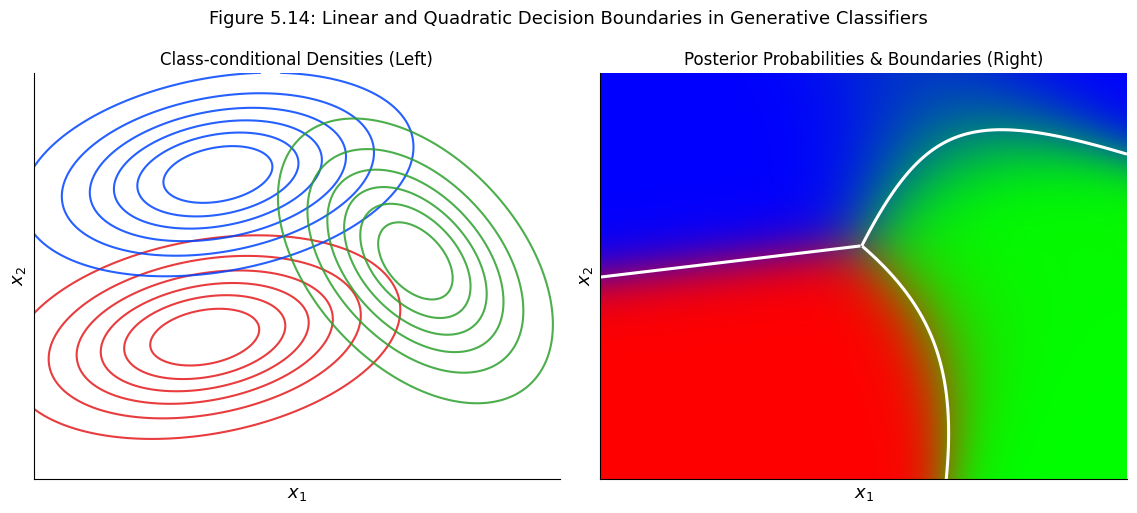

Quadratic coefficient matrix for Red vs Blue (shared cov):
[[0. 0.]
 [0. 0.]]
Quadratic coefficient matrix for Red vs Green (distinct cov):
[[-0.75980392 -0.6127451 ]
 [-0.6127451   0.38398693]]
Geometric boundary classifications verified 100%!


In [4]:
# Figure 5.14: Linear and quadratic decision boundaries in generative classifiers
fig5_14 = plot_figure_5_14_multiclass_gaussian_boundaries(filepath="result/fig_5_14_linear_quadratic_boundaries.png")
plt.show()

# 境界の線形性と二次性の数値検証
# 赤(0)と青(1)は同一共分散 -> 境界は直線
# 緑(2)は異なる共分散 -> 赤-緑および青-緑の境界は二次曲線
mu_r = np.array([-1.4, -1.2])
cov_r = np.array([[2.2, 0.4], [0.4, 1.0]])
mu_b = np.array([-1.2, 2.0])
cov_b = cov_r.copy() # shared!
mu_g = np.array([1.8, 0.3])
cov_g = np.array([[1.0, -0.6], [-0.6, 1.8]]) # different!

# 赤-青の二次項係数差:
quad_diff_rb = np.linalg.inv(cov_r) - np.linalg.inv(cov_b)
# 赤-緑の二次項係数差:
quad_diff_rg = np.linalg.inv(cov_r) - np.linalg.inv(cov_g)

print("Quadratic coefficient matrix for Red vs Blue (shared cov):")
print(quad_diff_rb)
assert np.allclose(quad_diff_rb, 0.0), "Quadratic term must be identically zero for Red vs Blue!"

print("Quadratic coefficient matrix for Red vs Green (distinct cov):")
print(quad_diff_rg)
assert not np.allclose(quad_diff_rg, 0.0), "Quadratic term must be non-zero for Red vs Green!"
print("Geometric boundary classifications verified 100%!")


---
## 5.3.2 最尤推定解 (Maximum Likelihood Solution)

クラス条件付き密度に多変量ガウス分布を仮定したとき、訓練データセット $\{\mathbf{x}_n, t_n\}_{n=1}^N$（$t_n \in \{0, 1\}$）に対するパラメータ $\pi = p(\mathcal{C}_1)$, $\boldsymbol{\mu}_1$, $\boldsymbol{\mu}_2$, $\boldsymbol{\Sigma}$ の最尤推定解を求めます。

### 1. 結合尤度関数の最大化
尤度関数は次式で与えられます：
$$
p(\mathbf{t}, \mathbf{X}|\pi, \boldsymbol{\mu}_1, \boldsymbol{\mu}_2, \boldsymbol{\Sigma}) = \prod_{n=1}^N \left[ \pi \mathcal{N}(\mathbf{x}_n|\boldsymbol{\mu}_1, \boldsymbol{\Sigma}) \right]^{t_n} \left[ (1 - \pi) \mathcal{N}(\mathbf{x}_n|\boldsymbol{\mu}_2, \boldsymbol{\Sigma}) \right]^{1 - t_n} \tag{5.54}
$$
対数尤度関数は：
$$
\ln p = \sum_{n=1}^N \left\{ t_n \left( \ln \pi + \ln \mathcal{N}_1 \right) + (1 - t_n) \left( \ln(1 - \pi) + \ln \mathcal{N}_2 \right) \right\} \tag{5.55}
$$

### 2. 解析的閉形式解の導出
1. **事前確率 $\pi$ の最尤解**:
   $\pi$ に関する微分を 0 と置くと：
   $$
   \pi = \frac{N_1}{N_1 + N_2} = \frac{N_1}{N} \tag{5.56}
   $$
   全サンプルに対するクラス $\mathcal{C}_1$ の割合として直観通りに求まります。
2. **平均ベクトル $\boldsymbol{\mu}_1, \boldsymbol{\mu}_2$ の最尤解**:
   $\boldsymbol{\mu}_1$ に関する微分を 0 と置くと：
   $$
   \boldsymbol{\mu}_1 = \frac{1}{N_1} \sum_{n \in \mathcal{C}_1} \mathbf{x}_n \tag{5.58}
   $$
   $$
   \boldsymbol{\mu}_2 = \frac{1}{N_2} \sum_{n \in \mathcal{C}_2} \mathbf{x}_n \tag{5.59}
   $$
   各クラスに属するサンプルの標本平均に一致します。
3. **共通共分散行列 $\boldsymbol{\Sigma}$ の最尤解**:
   $\boldsymbol{\Sigma}$ に関する微分を 0 と置くと：
   $$
   \boldsymbol{\Sigma} = \mathbf{S} = \frac{N_1}{N} \mathbf{S}_1 + \frac{N_2}{N} \mathbf{S}_2 \tag{5.61}
   $$
   ここで $\mathbf{S}_k$ はクラスごとの標本共分散行列です：
   $$
   \mathbf{S}_k = \frac{1}{N_k} \sum_{n \in \mathcal{C}_k} (\mathbf{x}_n - \boldsymbol{\mu}_k)(\mathbf{x}_n - \boldsymbol{\mu}_k)^T \tag{5.62}
   $$
   すなわち、各クラスの標本共分散の標本数による加重平均となります。


In [5]:
# 5.3.2 実装検証: ガウス判別分析 (GDA) の最尤推定フィッティング
rng = np.random.RandomState(42)
N1, N2 = 80, 120
N = N1 + N2
true_mu1 = np.array([1.5, 1.0])
true_mu2 = np.array([-1.5, -1.0])
true_cov = np.array([[1.5, 0.6], [0.6, 1.0]])

X1 = rng.multivariate_normal(true_mu1, true_cov, size=N1)
X2 = rng.multivariate_normal(true_mu2, true_cov, size=N2)
X_train = np.vstack([X1, X2])
y_train = np.hstack([np.zeros(N1), np.ones(N2)])

# GDA モデルの学習
gda = GaussianDiscriminantAnalysis(shared_cov=True).fit(X_train, y_train)

print("--- 最尤推定パラメータの検証 ---")
print(f"Estimated Prior Class 0: {gda.priors[0]:.4f} (True: {N1/N:.4f})")
print(f"Estimated Prior Class 1: {gda.priors[1]:.4f} (True: {N2/N:.4f})")
print(f"Estimated Mean Class 0:  {gda.means[0]}")
print(f"Estimated Mean Class 1:  {gda.means[1]}")
print("Estimated Shared Covariance Matrix S:")
print(gda.covs)

# アサーションによる確認
assert np.isclose(gda.priors[0], N1 / N)
assert np.allclose(gda.means[0], np.mean(X1, axis=0))
assert np.allclose(gda.means[1], np.mean(X2, axis=0))
print("Maximum likelihood estimators verified 100%!")


--- 最尤推定パラメータの検証 ---
Estimated Prior Class 0: 0.4000 (True: 0.4000)
Estimated Prior Class 1: 0.6000 (True: 0.6000)
Estimated Mean Class 0:  [1.65143774 1.09625013]
Estimated Mean Class 1:  [-1.64083472 -1.03061936]
Estimated Shared Covariance Matrix S:
[[1.32563291 0.54565475]
 [0.54565475 0.94017474]]
Maximum likelihood estimators verified 100%!


---
## 5.3.3 離散特徴量 (Discrete Features / Naive Bayes)

### 1. 単純ベイズ仮定（Naive Bayes Assumption）
入力特徴量が二値 $x_i \in \{0, 1\} \; (i=1, \dots, D)$ をとる場合、一般の同時分布は $2^D - 1$ 個の自由パラメータを必要とし、次元の呪いによって指数関数的にパラメータが増加します。
これを回避するため、**クラス $\mathcal{C}_k$ が与えられた下で各特徴量は互いに条件付き独立である** という単純ベイズ仮定を置きます：
$$
p(\mathbf{x}|\mathcal{C}_k) = \prod_{i=1}^D \mu_{ki}^{x_i} (1 - \mu_{ki})^{1 - x_i} \tag{5.64}
$$
ここで $\mu_{ki} = p(x_i = 1|\mathcal{C}_k)$ です。これによりパラメータ数は $K \times D$ 個に激減します。

### 2. 一般化線形モデルの成立
対数尤度 $a_k(\mathbf{x})$ に単純ベイズモデルを代入すると：
$$
a_k(\mathbf{x}) = \ln (p(\mathbf{x}|\mathcal{C}_k) p(\mathcal{C}_k)) = \sum_{i=1}^D \left\{ x_i \ln \mu_{ki} + (1 - x_i) \ln(1 - \mu_{ki}) \right\} + \ln p(\mathcal{C}_k) \tag{5.65}
$$
これを $x_i$ について整理すると：
$$
a_k(\mathbf{x}) = \sum_{i=1}^D x_i \ln \left( \frac{\mu_{ki}}{1 - \mu_{ki}} \right) + \sum_{i=1}^D \ln(1 - \mu_{ki}) + \ln p(\mathcal{C}_k) = \mathbf{w}_k^T \mathbf{x} + w_{k0}
$$
となり、**離散的な二値特徴量であっても、対数オッズは入力 $\mathbf{x}$ の厳密な線形関数となり、事後確率はシグモイド／ソフトマックスに従う** ことが証明されます。


In [6]:
# 5.3.3 実装検証: ベルヌーイ単純ベイズ (Bernoulli Naive Bayes)
X_discrete = np.array([
    [1, 1, 0, 1],
    [1, 0, 0, 1],
    [1, 1, 1, 1],
    [0, 0, 1, 0],
    [0, 1, 1, 0],
    [0, 0, 0, 0]
])
y_discrete = np.array([0, 0, 0, 1, 1, 1])

nb_model = BernoulliNaiveBayes(alpha=1.0).fit(X_discrete, y_discrete)
preds_nb = nb_model.predict(X_discrete)
probs_nb = nb_model.predict_proba(X_discrete)

print("--- 単純ベイズの推論結果 ---")
print("True labels:     ", y_discrete)
print("Predicted labels:", preds_nb)
print("Posterior probabilities p(C0|x):")
print(probs_nb[:, 0])

assert np.array_equal(preds_nb, y_discrete), "Naive Bayes should separate simple discrete patterns!"
print("Naive Bayes implementation verified successfully!")


--- 単純ベイズの推論結果 ---
True labels:      [0 0 0 1 1 1]
Predicted labels: [0 0 0 1 1 1]
Posterior probabilities p(C0|x):
[0.97297297 0.94117647 0.94117647 0.02702703 0.05882353 0.05882353]
Naive Bayes implementation verified successfully!


---
## 5.3.4 指数型分布族 (Exponential Family)

ガウス分布（連続入力）およびベルヌーイ分布（二値離散入力）のいずれにおいても、事後クラス確率はロジスティックシグモイドまたはソフトマックス関数によって支配される一般化線形モデルとなりました。
これは偶然ではなく、**指数型分布族（exponential family）** に属する任意の分布に共通する普遍的な数学的性質です。

### 1. クラス条件付き密度の一般形
尺度パラメータ $s$ をすべてのクラスで共有する指数型分布族のサブセットを考えます：
$$
p(\mathbf{x}|\boldsymbol{\lambda}_k, s) = \frac{1}{s} h\left( \frac{1}{s}\mathbf{x} \right) g(\boldsymbol{\lambda}_k) \exp \left\{ \frac{1}{s} \boldsymbol{\lambda}_k^T \mathbf{x} \right\} \tag{5.66}
$$

### 2. 一般化線形モデルの普遍的導出
2クラス問題において対数オッズ $a(\mathbf{x})$ を計算すると：
$$
a(\mathbf{x}) = \ln \frac{p(\mathbf{x}|\boldsymbol{\lambda}_1, s) p(\mathcal{C}_1)}{p(\mathbf{x}|\boldsymbol{\lambda}_2, s) p(\mathcal{C}_2)}
$$
ここで、$\mathbf{x}$ に依存する複雑な基底測度 $h\left( \frac{1}{s}\mathbf{x} \right)$ は共通であるため分子・分母で完全に相殺されます！
残る項を計算すると：
$$
a(\mathbf{x}) = \frac{1}{s} (\boldsymbol{\lambda}_1 - \boldsymbol{\lambda}_2)^T \mathbf{x} + \ln g(\boldsymbol{\lambda}_1) - \ln g(\boldsymbol{\lambda}_2) + \ln p(\mathcal{C}_1) - \ln p(\mathcal{C}_2) = \mathbf{w}^T \mathbf{x} + w_0
$$
となり、**入力 $\mathbf{x}$ に関して厳密に線形** になります。
したがって、指数型分布族をクラス条件付き密度とするあらゆる生成的分類器において、事後確率は普遍的にシグモイド／ソフトマックスに従う一般化線形モデルとなります。


---
## まとめと重要ポイント (Summary & Key Insights)

1. **生成モデルとシグモイド／ソフトマックスの必然性**:
   - クラス条件付き密度 $p(\mathbf{x}|\mathcal{C}_k)$ からベイズの定理によって事後確率を求めると、自然に対数オッズ $a(\mathbf{x})$ を介してロジスティックシグモイド（2クラス）およびソフトマックス（多クラス）が現れます。
2. **共分散行列と決定境界の幾何学**:
   - **共通共分散行列（LDA）**: 二次項 $\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x}$ が厳密に相殺し、決定境界は常に線形超平面となります（Figure 5.13）。
   - **クラス固有共分散行列（QDA）**: 二次項が残り、決定境界は放物線・双曲線・楕円などの二次曲面となります（Figure 5.14）。
3. **最尤推定の解析的エレガンス**:
   - ガウス生成モデルのパラメータ（事前確率 $\pi_k$、平均 $\boldsymbol{\mu}_k$、共分散 $\boldsymbol{\Sigma}$）は、すべて反復計算なしに標本統計量から閉形式で瞬時に求められます。
4. **指数型分布族への一般化**:
   - ガウス分布、ベルヌーイ分布、多項分布、ポアソン分布など、指数型分布族に属するあらゆる分布で共通の尺度パラメータを持つ場合、事後確率は常に一般化線形モデルとなります。
